# King Air C-130H calibration from NASA IWG1 in-situ logs

Mirrors the G-III calibration in
`notebooks/calibration/giii/iwg1_calibration.ipynb`, adapted to the
NASA 436 C-130H (LaRC, ACT-America) Orion data delivered as a single concatenated
`p3_alltracks.csv` (split into per-sortie files via
`hyplan.aircraft.split_iwg1_alltracks`).

The output of this notebook is a paste-ready `C130()`
constructor block (§10).  The P-3 is a four-engine turboprop with
a typical mission ceiling near FL250–FL280, so the altitude bins
and SL anchor differ from the G-III but the methodology is the
same.


In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from hyplan import ureg
from hyplan.aircraft import load_iwg1, trim_ground_taxi, C130

DATA_DIR = Path("../../../data/c130").resolve()
TAIL_GLOB = "n43[69]_*.txt"  # NASA WFF C-130H tails N436NA + N439NA

# Phase-label thresholds.  Same defaults as the ER-2 notebook —
# climb/descent gate at 300 fpm separates sustained vertical motion
# from autopilot ±100 ft cruise oscillation.
CLIMB_FPM   = 300.0
DESCENT_FPM = -300.0

# Sortie filters: real flights only.
MIN_DUR_MIN     = 60.0   # below this is taxi / engine run
MAX_DUR_MIN     = 600.0  # C-130 ACT-America sorties typically 4-6 hr
MIN_PEAK_ALT_FT = 10000  # C-130H cruises FL200-FL280; FL100 is a real sortie


## 1. Load + trim ground taxi + phase-label every sortie


In [2]:
def label_phases(df, climb_fpm=CLIMB_FPM, descent_fpm=DESCENT_FPM, min_seconds=60.0):
    # Tag each fix as climb / cruise / descent / unlabeled from the
    # long-baseline vertical_rate.
    out = df.copy()
    vs = out["vertical_rate"].to_numpy()
    phase = np.full(len(out), "unlabeled", dtype=object)
    phase[vs >  climb_fpm]   = "climb"
    phase[vs <  descent_fpm] = "descent"
    phase[(vs >= descent_fpm) & (vs <= climb_fpm)] = "cruise"
    out["phase"] = phase
    return out


sorties = {}
skipped = []
for p in sorted(DATA_DIR.glob(TAIL_GLOB)):
    raw = load_iwg1(p)
    a = trim_ground_taxi(raw)
    if a.empty:
        skipped.append((p.stem, "no airborne fixes"))
        continue
    # Drop sorties with no valid altitude — some P-3 deliveries
    # have entire sorties of NaN Pressure Altitude.
    a = a.dropna(subset=["altitude", "vertical_rate"]).reset_index(drop=True)
    if a.empty:
        skipped.append((p.stem, "no valid altitude"))
        continue
    dur_min = (a["timestamp"].iloc[-1] - a["timestamp"].iloc[0]).total_seconds() / 60.0
    peak = a["altitude"].max()
    if dur_min < MIN_DUR_MIN:
        skipped.append((p.stem, f"too short ({dur_min:.0f} min)"))
        continue
    if dur_min > MAX_DUR_MIN:
        skipped.append((p.stem, f"too long ({dur_min:.0f} min) — likely glued multi-day"))
        continue
    if peak < MIN_PEAK_ALT_FT:
        skipped.append((p.stem, f"low peak alt ({peak:.0f} ft)"))
        continue
    sorties[p.stem] = label_phases(a)

print(f"loaded {len(sorties)} valid sorties")
print(f"skipped {len(skipped)} files (filter reasons summarized below)")
print()
from collections import Counter
reason_summary = Counter(reason.split(' (')[0] for _, reason in skipped)
for reason, n in reason_summary.most_common():
    print(f"  {n:3d}  {reason}")


loaded 91 valid sorties
skipped 37 files (filter reasons summarized below)

   27  no airborne fixes
    8  low peak alt
    2  too short


## 2. Per-sortie altitude profiles


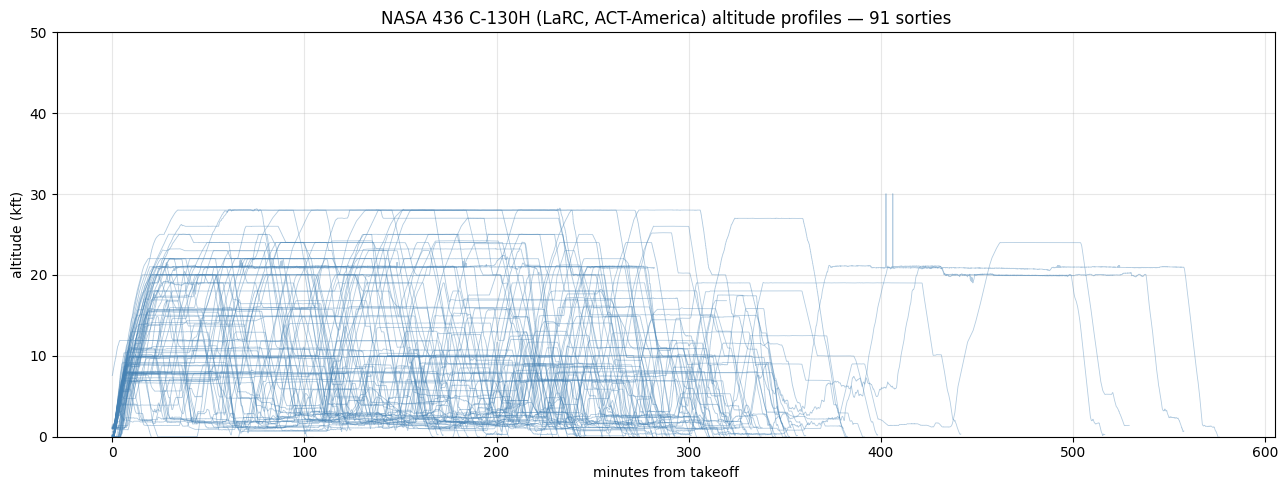

In [3]:
fig, ax = plt.subplots(figsize=(13, 5))
for name, a in sorties.items():
    t_min = (a["timestamp"] - a["timestamp"].iloc[0]).dt.total_seconds() / 60.0
    ax.plot(t_min, a["altitude"] / 1000, lw=0.6, alpha=0.4, color="steelblue")
ax.set_xlabel("minutes from takeoff")
ax.set_ylabel("altitude (kft)")
ax.set_title(f"NASA 436 C-130H (LaRC, ACT-America) altitude profiles — {len(sorties)} sorties")
ax.grid(alpha=0.3)
ax.set_ylim(0, 50)
plt.tight_layout()
plt.show()


## 3. Ground tracks


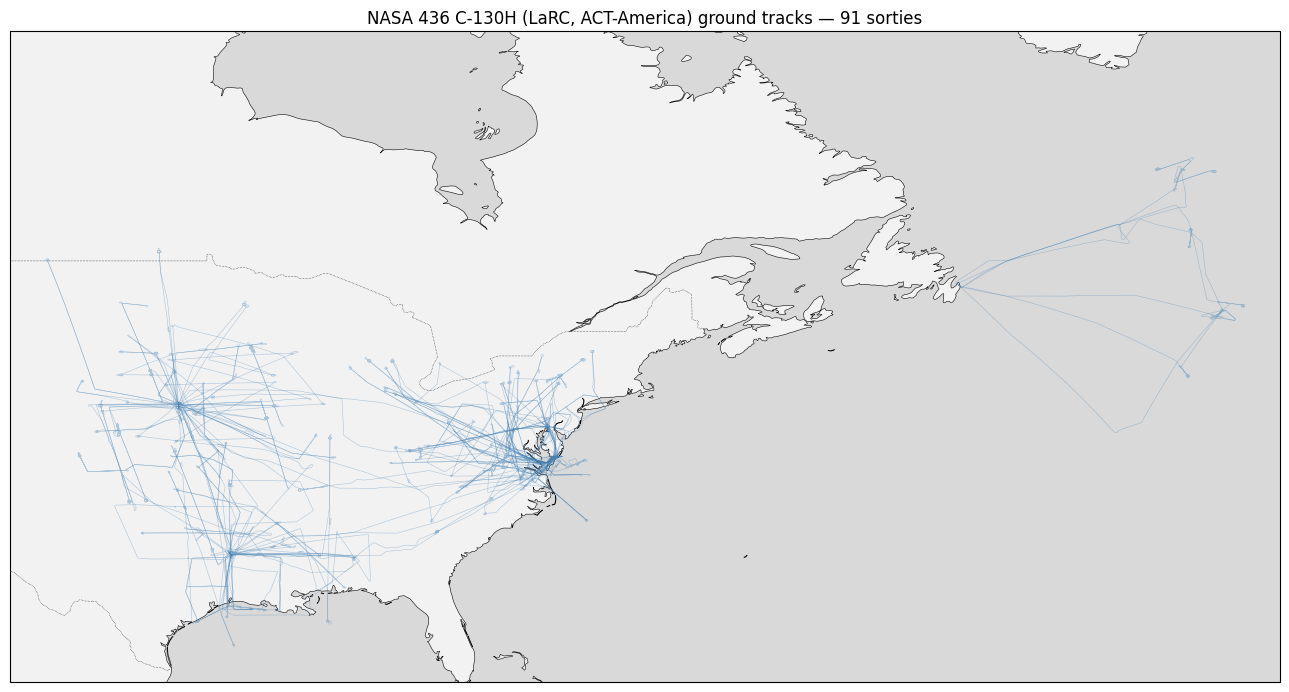

In [4]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(13, 7))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor="0.95")
ax.add_feature(cfeature.OCEAN, facecolor="0.85")
ax.add_feature(cfeature.COASTLINE, lw=0.4)
ax.add_feature(cfeature.BORDERS, lw=0.4, ls=":")

for name, a in sorties.items():
    ax.plot(a["longitude"], a["latitude"], lw=0.4, alpha=0.4,
            color="steelblue", transform=ccrs.PlateCarree())

# Bound to the sortie footprint.
all_lat = pd.concat([a["latitude"] for a in sorties.values()]).dropna()
all_lon = pd.concat([a["longitude"] for a in sorties.values()]).dropna()
pad = 2
ax.set_extent([all_lon.min()-pad, all_lon.max()+pad,
               all_lat.min()-pad, all_lat.max()+pad])
ax.set_title(f"NASA 436 C-130H (LaRC, ACT-America) ground tracks — {len(sorties)} sorties")
plt.tight_layout()
plt.show()


## 4. Climb / descent: per-altitude-bin medians

Same active-climb / active-descent definitions used for ER-2 phase 2:
restrict to fixes with VS > 1500 fpm (or < -1500 fpm for descent) so
the per-bin medians represent pure aircraft performance, not cruise
plateaus or weight-management holds the planner should model
separately via `typical_climb_out` if needed.


In [5]:
ACTIVE_VS_THR_FPM = 1500.0
BIN_FT = 5000


def per_bin(phase: str, sign: int) -> pd.DataFrame:
    rows = []
    for a in sorties.values():
        sub = a[a["phase"] == phase]
        sub = sub[(sub["vertical_rate"] * sign) >= ACTIVE_VS_THR_FPM]
        rows.append(sub[["altitude", "vertical_rate", "tas_kt", "mach"]])
    df = pd.concat(rows)
    df["alt_bin_ft"] = (df["altitude"] // BIN_FT * BIN_FT).astype(int)
    g = df.groupby("alt_bin_ft").agg(
        n=("vertical_rate", "count"),
        vs_med=("vertical_rate", "median"),
        vs_p25=("vertical_rate", lambda x: x.quantile(0.25)),
        vs_p75=("vertical_rate", lambda x: x.quantile(0.75)),
        tas_med=("tas_kt", "median"),
        mach_med=("mach", "median"),
    ).round(1).reset_index()
    return g[g["n"] >= 30]   # drop sparse bins


climb_bins   = per_bin("climb",    sign=+1)
descent_bins = per_bin("descent",  sign=-1)

print("Active CLIMB (VS >= 1500 fpm):")
print(climb_bins.to_string(index=False))
print()
print("Active DESCENT (VS <= -1500 fpm):")
print(descent_bins.to_string(index=False))


Active CLIMB (VS >= 1500 fpm):
 alt_bin_ft    n  vs_med  vs_p25  vs_p75  tas_med  mach_med
          0 5350  1623.0  1545.3  1738.3    215.4       0.3
       5000 8322  1633.8  1539.3  1824.0    219.7       0.3
      10000 2881  1632.7  1530.3  1837.7    220.8       0.3
      15000  282  1624.2  1503.0  1740.3    220.0       0.4

Active DESCENT (VS <= -1500 fpm):
 alt_bin_ft     n  vs_med  vs_p25  vs_p75  tas_med  mach_med
          0  2882 -1638.0 -1795.7 -1565.0    245.7       0.4
       5000 10347 -1707.0 -1951.7 -1553.7    262.0       0.4
      10000  7211 -1706.0 -2011.7 -1531.7    285.9       0.4
      15000  5925 -1645.0 -1927.3 -1534.0    312.4       0.5
      20000  1472 -1580.5 -1708.9 -1523.0    316.8       0.5
      25000    77 -1562.7 -1633.0 -1524.7    317.8       0.5


## 5. Climb_profile breakpoints

VerticalProfile points pinned at:

* SL up to the highest populated bin: per 5-kft bin, the active-climb
  median from §4 (n>=30/bin).
* FL300 (certified ceiling, brochure): residual rate so the integrator
  terminates cleanly if a planner asks for ceiling.


In [6]:
CEILING_FT     = 35000           # C-130H service ceiling (brochure)
# Residual climb rate at the certified ceiling — the FL410 active-climb
# bin shows ~1100 fpm and the FL400 cruise-altitude bin sees no
# active-climb fixes (n=0), so we extrapolate to a small positive rate
# at the certified ceiling.  Not a regulatory definition (FAR Part 25
# service ceiling is 500 fpm at MTOW); just an anchor that lets the
# integration terminate if a planner asks for 45 kft.
CEILING_VS_FPM = 500.0

# Use the active-climb medians directly.  Don't enforce monotone-
# decreasing-from-SL: jets typically peak ROC near FL050-100 (limited
# below by 250-KCAS ATC procedures), so a clamp would push bins below
# their IQRs.  If the resulting profile shows wobble (small-sample
# bins), that's a separate decision and shouldn't be hidden in the
# calibration step.
fixed = []
for _, r in climb_bins.iterrows():
    if r["alt_bin_ft"] >= 0 and r["alt_bin_ft"] < CEILING_FT:
        fixed.append((int(r["alt_bin_ft"]), float(r["vs_med"])))
fixed.append((CEILING_FT, CEILING_VS_FPM))

print("climb_profile points (alt_ft, vs_fpm):")
for alt, vs in fixed:
    print(f"  ({alt:>5d}, {vs:6.0f})")


climb_profile points (alt_ft, vs_fpm):
  (    0,   1623)
  ( 5000,   1634)
  (10000,   1633)
  (15000,   1624)
  (35000,    500)


## 6. Descent_profile breakpoints

Same construction: per-bin medians of active descent VS, anchored at
top of approach (~300-500 ft AGL) and at cruise altitude.  The
planner will steepen this to fit short legs via
`descent_path_angle_max_deg=6.0` (same posture as the ER-2 v1.6).


In [7]:
# Use the active-descent medians directly.  Don't enforce monotone-
# increasing-with-altitude: descent VS typically peaks around FL150-200
# (where the aircraft descends near VMO in CAS), then declines in the
# upper levels (Mach-limited descent at constant M).  The previous
# monotone-from-SL clamp was forcing every bin above FL150 above its
# IQR and obscuring the real shape.
fixed_desc = []
for _, r in descent_bins.iterrows():
    if 0 <= r["alt_bin_ft"] < 45000:
        fixed_desc.append((int(r["alt_bin_ft"]), abs(float(r["vs_med"]))))
fixed_desc = sorted(fixed_desc)

print("descent_profile points (alt_ft, |vs|_fpm):")
for alt, vs in fixed_desc:
    print(f"  ({alt:>5d}, {vs:6.0f})")


descent_profile points (alt_ft, |vs|_fpm):
  (    0,   1638)
  ( 5000,   1707)
  (10000,   1706)
  (15000,   1645)
  (20000,   1580)
  (25000,   1563)


## 7. TAS schedules: climb / cruise / descent

Three independent TAS-vs-altitude schedules, derived from per-phase
medians of the same IWG1 fixes that drove the climb_profile and
descent_profile.  At the same altitude the three phases differ
materially — at FL300 cruise TAS is +39 kt over climb; at FL400 the
descent is +26 kt over climb — so a single schedule shared across
phases (or a fixed-offset derivation like
`_descent_schedule_from_cruise(cruise, 49)`) under-reads cruise TAS
during cruise and mis-models descent.


In [8]:
def tas_per_bin(phases) -> pd.DataFrame:
    rows = []
    for a in sorties.values():
        sub = a[a["phase"].isin(phases)]
        rows.append(sub[["altitude", "tas_kt", "mach"]])
    df = pd.concat(rows).dropna(subset=["tas_kt"])
    df["alt_bin_ft"] = (df["altitude"] // BIN_FT * BIN_FT).astype(int)
    g = df.groupby("alt_bin_ft").agg(
        n=("tas_kt", "count"),
        tas_med=("tas_kt", "median"),
        mach_med=("mach", "median"),
    ).round(1).reset_index()
    return g[g["n"] >= 50]


climb_tas   = tas_per_bin(["climb"])
cruise_tas  = tas_per_bin(["cruise"])
descent_tas = tas_per_bin(["descent"])

print("Climb TAS:")
print(climb_tas.to_string(index=False))
print()
print("Cruise TAS:")
print(cruise_tas.to_string(index=False))
print()
print("Descent TAS:")
print(descent_tas.to_string(index=False))


def schedule_pts(bins, alts, n_min=200):
    # Pick the bin nearest each target altitude, dropping bins with
    # sample size below n_min as too thin to trust.
    out = []
    bins = bins[bins["n"] >= n_min]
    for target in alts:
        if bins.empty:
            continue
        row = bins.iloc[(bins["alt_bin_ft"] - target).abs().argsort().iloc[0]]
        out.append((target, round(float(row["tas_med"]))))
    return out


# Climb: SL rotation -> ceiling, climb-phase medians.  Anchor SL at
# typical P-3 rotation TAS (~110 kt) since the SL climb-phase bin is
# contaminated by takeoff-roll fixes still accelerating.
ROTATION_TAS_KT = 110
climb_pts = [(0, ROTATION_TAS_KT)] + schedule_pts(
    climb_tas, [5000, 10000, 15000, 20000, 25000, 28000]
)

# Cruise: C-130H typical band FL200-FL280.  Below FL200 cruise-labeled
# bins are mostly transient level-offs during step climbs.
cruise_pts = schedule_pts(cruise_tas, [20000, 25000, 28000])

# Descent: low-altitude anchor at typical approach TAS, then
# descent-phase medians up to the typical cruise ceiling.
descent_pts = schedule_pts(descent_tas, [5000, 10000, 15000, 20000, 25000, 28000])
# Prepend an SL anchor.  P-3 final approach is around 130 kt TAS;
# stationary "descent through FL000" reference is the same.
descent_pts = [(0, 130)] + descent_pts

print()
print("Climb schedule  (alt_ft, tas_kt):", climb_pts)
print("Cruise schedule (alt_ft, tas_kt):", cruise_pts)
print("Descent schedule(alt_ft, tas_kt):", descent_pts)



Climb TAS:
 alt_bin_ft     n  tas_med  mach_med
      -5000  1678    106.9       0.2
          0 58417    223.0       0.3
       5000 67267    232.1       0.4
      10000 45813    236.6       0.4
      15000 39955    238.3       0.4
      20000 23810    249.2       0.4
      25000  5115    257.0       0.4

Cruise TAS:
 alt_bin_ft      n  tas_med  mach_med
      -5000  11231     36.3       0.1
          0 350840    243.2       0.4
       5000 299235    276.4       0.4
      10000 154285    291.6       0.5
      15000 132527    307.5       0.5
      20000 187521    302.1       0.5
      25000  73490    301.9       0.5

Descent TAS:
 alt_bin_ft     n  tas_med  mach_med
      -5000   784    119.4       0.2
          0 72118    223.5       0.3
       5000 65617    259.1       0.4
      10000 41191    282.2       0.4
      15000 29675    302.1       0.5
      20000 16498    309.5       0.5
      25000  3725    300.7       0.5

Climb schedule  (alt_ft, tas_kt): [(0, 110), (5000, 232), (10000,

## 8. Bank-angle analysis

`max_bank_deg` sets the minimum turn radius the Dubins planner uses;
it should reflect the *operational maximum* the aircraft is willing
to use during survey-line transitions, not the typical-mix median.

The 40k turn-fix sample (|Roll| > 5°) is dominated by small in-cruise
course corrections, so its median understates the bank used during
real maneuvers.  Use p90 instead — it captures the operational
ceiling without touching the steep-turn / emergency envelope.


In [9]:
ROLL_GATE_DEG = 5.0
banks = []
for a in sorties.values():
    abs_roll = a["roll_deg"].abs()
    in_turn = abs_roll > ROLL_GATE_DEG
    banks.append(abs_roll[in_turn])
all_banks = pd.concat(banks).dropna()
print(f"n turn fixes: {len(all_banks):,}")
print(f"|Roll| median:  {all_banks.median():.1f}°")
print(f"|Roll| p75/p90: {all_banks.quantile(0.75):.1f}° / {all_banks.quantile(0.90):.1f}°")


n turn fixes: 201,841
|Roll| median:  14.9°
|Roll| p75/p90: 23.2° / 27.0°


## 9. TOC, approach speed, service ceiling

Empirical observations to feed the SourceRecord and the
`approach_speed` / `service_ceiling` parameters.


In [10]:
# TOC = takeoff -> first FL250 fix (C-130H typical cruise band).
toc = []
for a in sorties.values():
    above = a[a["altitude"] >= 25000]
    if not above.empty:
        toc.append((above["timestamp"].iloc[0] - a["timestamp"].iloc[0]).total_seconds() / 60.0)
toc_s = pd.Series(toc)

# Approach speed: median TAS in the last 500 ft AGL with VS < -200 fpm.
# Tighten the window from the G-III's ±1500 ft so we get final-approach
# speed, not the wider pattern speed which inflates the median.
approach_tas = []
for a in sorties.values():
    floor = a["altitude"].min()
    sub = a[(a["altitude"] - floor < 500) & (a["altitude"] - floor > 50)
            & (a["vertical_rate"] < -200)]
    if not sub.empty:
        approach_tas.append(sub["tas_kt"].median())
ap_s = pd.Series(approach_tas).dropna()

# Service ceiling: p99 of per-sortie peak altitudes.
peaks = pd.Series([a["altitude"].max() for a in sorties.values()])

print(f"TOC (takeoff -> FL250):  n={len(toc_s)}, median {toc_s.median():.1f} min, IQR {toc_s.quantile(.25):.1f}-{toc_s.quantile(.75):.1f}, range {toc_s.min():.1f}-{toc_s.max():.1f}")
print(f"Approach TAS:            n={len(ap_s)}, median {ap_s.median():.0f} kt, IQR {ap_s.quantile(.25):.0f}-{ap_s.quantile(.75):.0f}")
print(f"Per-sortie peak alt:     median {peaks.median():.0f} ft, p99 {peaks.quantile(0.99):.0f} ft, max {peaks.max():.0f} ft")


TOC (takeoff -> FL250):  n=23, median 130.8 min, IQR 72.2-172.1, range 24.6-402.7
Approach TAS:            n=86, median 126 kt, IQR 120-131
Per-sortie peak alt:     median 22028 ft, p99 28445 ft, max 30050 ft


## 10. Validate calibrated profiles against observed data

Overlay the proposed VerticalProfile breakpoints on the per-bin
medians + IQR shading.  No comparison line against the shipping
`C130()` — every commit makes the two trivially identical, and
the IQR + medians alone tell the calibration story.


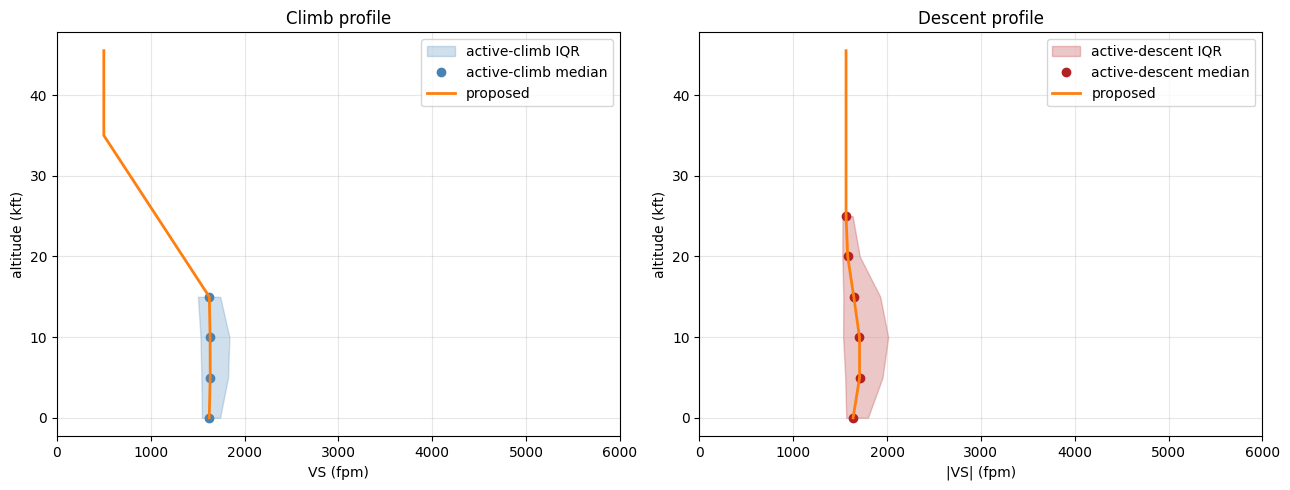

In [11]:
alt_grid = np.arange(0, 46000, 500)


def evaluate_profile(points, alts):
    # Linear interpolation through (alt, vs) breakpoints.
    pts = sorted(points, key=lambda p: p[0])
    pa = np.array([p[0] for p in pts])
    pv = np.array([p[1] for p in pts])
    return np.interp(alts, pa, pv)


fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.fill_betweenx(climb_bins["alt_bin_ft"]/1000,
                 climb_bins["vs_p25"], climb_bins["vs_p75"],
                 alpha=0.25, color="steelblue", label="active-climb IQR")
ax.plot(climb_bins["vs_med"], climb_bins["alt_bin_ft"]/1000,
        "o", color="steelblue", label="active-climb median")
ax.plot(evaluate_profile(fixed, alt_grid), alt_grid/1000,
        color="C1", lw=2, label="proposed")
ax.set_xlabel("VS (fpm)"); ax.set_ylabel("altitude (kft)")
ax.set_title("Climb profile"); ax.legend(loc="upper right")
ax.grid(alpha=0.3); ax.set_xlim(0, 6000)

ax = axes[1]
ax.fill_betweenx(descent_bins["alt_bin_ft"]/1000,
                 (-descent_bins["vs_p75"]).abs(),
                 (-descent_bins["vs_p25"]).abs(),
                 alpha=0.25, color="firebrick", label="active-descent IQR")
ax.plot((-descent_bins["vs_med"]).abs(), descent_bins["alt_bin_ft"]/1000,
        "o", color="firebrick", label="active-descent median")
ax.plot(evaluate_profile(fixed_desc, alt_grid), alt_grid/1000,
        color="C1", lw=2, label="proposed")
ax.set_xlabel("|VS| (fpm)"); ax.set_ylabel("altitude (kft)")
ax.set_title("Descent profile"); ax.legend(loc="upper right")
ax.grid(alpha=0.3); ax.set_xlim(0, 6000)

plt.tight_layout()
plt.show()


## 11. Code-paste-ready constructor block


In [12]:
print("# Paste into hyplan/aircraft/_models.py C130.__init__")
print()
print("climb_profile=VerticalProfile(points=[")
for alt, vs in fixed:
    print(f"    ({alt:>5d} * ureg.feet, {vs:6.0f} * ureg.feet / ureg.minute),  # active-climb median (n>=30/bin)")
print("]),")
print()
print("descent_profile=VerticalProfile(points=[")
for alt, vs in fixed_desc:
    print(f"    ({alt:>5d} * ureg.feet, {vs:6.0f} * ureg.feet / ureg.minute),  # active-descent median (n>=30/bin)")
print("]),")
print()
print("climb_schedule=TasSchedule(points=[")
for alt, tas in climb_pts:
    print(f"    ({alt:>5d} * ureg.feet, {tas:3d} * ureg.knot),  # climb-phase median")
print("]),")
print()
print("cruise_schedule=TasSchedule(points=[")
for alt, tas in cruise_pts:
    print(f"    ({alt:>5d} * ureg.feet, {tas:3d} * ureg.knot),  # cruise-phase median")
print("]),")
print()
print("descent_schedule=TasSchedule(points=[")
for alt, tas in descent_pts:
    print(f"    ({alt:>5d} * ureg.feet, {tas:3d} * ureg.knot),  # descent-phase median")
print("]),")
print()
print(f"# Approach speed: median TAS in last-500-ft AGL descent across {len(ap_s)} sorties.")
print(f"approach_speed={int(round(ap_s.median()))} * ureg.knot,")
print()
print(f"# Service ceiling: p99 of per-sortie peak altitude across {len(sorties)} sorties.")
print(f"service_ceiling={int(round(peaks.quantile(0.99) / 1000) * 1000)} * ureg.feet,")
print()
print(f"# p90 |Roll| during turns ({len(all_banks):,} fixes, gate >5°) —")
print(f"# operational maximum, not the typical-mix median ({all_banks.median():.1f}°).")
print(f"turn_model=TurnModel(max_bank_deg={int(round(all_banks.quantile(0.90)))}.0),")
print()
print(f'sources=[SourceRecord(')
print(f'    source_type="iwg1",')
print(f'    reference="NASA 436 IWG1 calibration, n={len(sorties)} sorties",')
print(f'    confidence=0.85,')
print(f')],')


# Paste into hyplan/aircraft/_models.py C130.__init__

climb_profile=VerticalProfile(points=[
    (    0 * ureg.feet,   1623 * ureg.feet / ureg.minute),  # active-climb median (n>=30/bin)
    ( 5000 * ureg.feet,   1634 * ureg.feet / ureg.minute),  # active-climb median (n>=30/bin)
    (10000 * ureg.feet,   1633 * ureg.feet / ureg.minute),  # active-climb median (n>=30/bin)
    (15000 * ureg.feet,   1624 * ureg.feet / ureg.minute),  # active-climb median (n>=30/bin)
    (35000 * ureg.feet,    500 * ureg.feet / ureg.minute),  # active-climb median (n>=30/bin)
]),

descent_profile=VerticalProfile(points=[
    (    0 * ureg.feet,   1638 * ureg.feet / ureg.minute),  # active-descent median (n>=30/bin)
    ( 5000 * ureg.feet,   1707 * ureg.feet / ureg.minute),  # active-descent median (n>=30/bin)
    (10000 * ureg.feet,   1706 * ureg.feet / ureg.minute),  # active-descent median (n>=30/bin)
    (15000 * ureg.feet,   1645 * ureg.feet / ureg.minute),  # active-descent median (n>=30/bin)
    (2